# Calibration just based on mounted

Aggregated 23 files | Total live time: 2753.3 s


Aggregated 23 files | Total live time: 2753.3 s



=== BATCH PROCESSING SUMMARY ===
    run_index  timestamp_sec  rate_117_MeV  rate_133_MeV  total_rate
0           0        59.9225      1.176825      0.805675    1.982500
1           1       179.7065      0.825074      0.337620    1.162694
2           2       299.4445      1.134200      0.908155    2.042354
3           3       419.1485      1.042329      0.505877    1.548206
4           4       538.8150      0.711434      0.631758    1.343192
5           5       658.5165      0.985915      0.671578    1.657493
6           6       778.3075      0.931139      0.637326    1.568465
7           7       898.0755      1.085476      0.742067    1.827543
8           8      1017.7165      0.889654      0.675288    1.564942
9           9      1137.3380      0.722222      0.679473    1.401696
10         10      1257.0710      0.812035      0.587163    1.399198
11         11      1376.9230      0.937170      0.552020    1.489190
12         12      1496.6885      0.576341      0.470699    1.047040


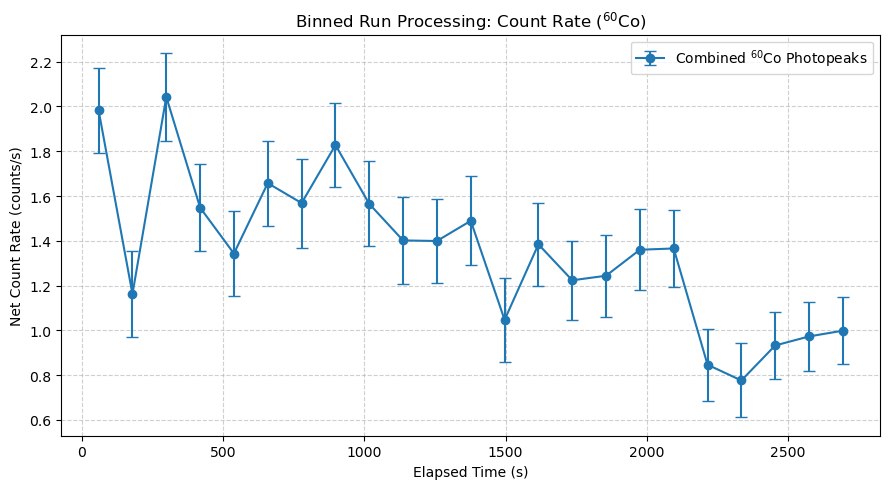

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import pathlib
import plotly.graph_objects as go
import plotly.io as pio

# ==============================================================================
# 1. CORE PEAK INTEGRATION FUNCTIONS
# ==============================================================================

def linear_bg(e, a, b):
    """Linear background function B(E) = a*E + b."""
    return a * e + b

def process_photopeak(energies, counts, peak_range, bg_left_range, bg_right_range):
    """
    Fits sidebands with a linear baseline, subtracts background, and integrates net counts.
    
    Parameters:
        energies (array): Array of energy values (MeV or Channel numbers).
        counts (array): Array of measured counts.
        peak_range (tuple): (E_min, E_max) Region of Interest (ROI) for the peak.
        bg_left_range (tuple): (E_min, E_max) Sideband region to the left of peak.
        bg_right_range (tuple): (E_min, E_max) Sideband region to the right of peak.
        
    Returns:
        dict containing net_counts, gross_counts, bg_counts, uncertainty, and fit parameters.
    """
    # Select masks for regions
    bg_mask = ((energies >= bg_left_range[0]) & (energies <= bg_left_range[1])) | \
              ((energies >= bg_right_range[0]) & (energies <= bg_right_range[1]))
    peak_mask = (energies >= peak_range[0]) & (energies <= peak_range[1])
    
    # Fit linear background to sidebands
    popt, _ = curve_fit(linear_bg, energies[bg_mask], counts[bg_mask])
    
    # Calculate counts in Peak ROI
    peak_energies = energies[peak_mask]
    peak_counts = counts[peak_mask]
    bg_in_peak = linear_bg(peak_energies, *popt)
    
    gross_counts = np.sum(peak_counts)
    bg_total = np.sum(bg_in_peak)
    net_counts = gross_counts - bg_total
    
    # Poisson statistical uncertainty
    uncertainty = np.sqrt(gross_counts + bg_total)
    
    return {
        "net_counts": net_counts,
        "gross_counts": gross_counts,
        "bg_counts": bg_total,
        "uncertainty": uncertainty,
        "popt": popt
    }


def load_and_bin_spectrum(filepath, bin_edges, raw_voltage=False):
    """
    Parses list-mode CSV. If raw_voltage=True, bins raw voltages directly.
    Otherwise, converts voltages to MeV using CALIB parameters before binning.
    """
    times = []
    voltages = []
    
    with open(filepath, 'r') as f:
        next(f)  # Skip header
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 2:
                try:
                    times.append(float(parts[-2]))
                    voltages.append(float(parts[-1]))
                except ValueError:
                    continue
                    
    time_s = np.array(times)
    duration_sec = time_s.max() - time_s.min() if len(time_s) > 0 else 1.0
    if duration_sec <= 0:
        duration_sec = 1.0

    voltages_arr = np.array(voltages)
    
    if raw_voltage:
        # Bin raw voltages directly without applying CALIB_M and CALIB_C
        counts, _ = np.histogram(voltages_arr, bins=bin_edges)
    else:
        # Convert voltages to energies (MeV) and bin
        event_energies = CALIB_M * voltages_arr + CALIB_C
        counts, _ = np.histogram(event_energies, bins=bin_edges)
    
    return counts, duration_sec

# Calibration parameters: E(V) = m * V + c
# Calibration from the linear fit of multiple known energy peaks
CALIB_M = 0.5923  # MeV / V
CALIB_C = 0.3994  # MeV

# Calibration just using the above_100k voltage region
CALIB_M = 3.006  # MeV / V
CALIB_C = -0.065 # MeV

# don't need the background subtraction really, Kolomensky advised against it
def analyze_co60_spectrum(filepath, bg_filepath=None):
    """
    Processes a sample spectrum file and optionally subtracts a room background file.
    """
    bin_edges = np.linspace(0.4, 1.7, 1301)
    energies = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 1. Load and bin sample spectrum
    counts, duration_sec = load_and_bin_spectrum(filepath, bin_edges)

    # 2. Subtract room background if provided
    if bg_filepath is not None:
        bg_counts, bg_duration = load_and_bin_spectrum(bg_filepath, bin_edges)
        
        # Time-scaling factor k = T_sample / T_bg
        time_scale = duration_sec / bg_duration
        
        # Subtract normalized room background
        counts = counts - (time_scale * bg_counts)

    # 3. Integrate photopeaks (sideband fit strips the remaining Compton continuum)
    p1_res = process_photopeak(
        energies, counts,
        peak_range=(1.12, 1.22), bg_left_range=(1.05, 1.10), bg_right_range=(1.24, 1.28)
    )

    p2_res = process_photopeak(
        energies, counts,
        peak_range=(1.29, 1.37), bg_left_range=(1.24, 1.28), bg_right_range=(1.39, 1.43)
        
    )

    # 4. Calculate count rates 
    rate_117 = p1_res["net_counts"] / duration_sec
    rate_117_err = p1_res["uncertainty"] / duration_sec

    rate_133 = p2_res["net_counts"] / duration_sec
    rate_133_err = p2_res["uncertainty"] / duration_sec

    return {
        "filename": filepath.name,
        "duration_sec": duration_sec,
        "rate_117_MeV": rate_117,
        "err_117_MeV": rate_117_err,
        "rate_133_MeV": rate_133,
        "err_133_MeV": rate_133_err,
        "total_rate": rate_117 + rate_133,
        "total_err": np.sqrt(rate_117_err**2 + rate_133_err**2),
    }


def process_run_directory(data_dir, room_bg_file=None):
    directory = pathlib.Path(data_dir)
    results = []
    file_list = sorted(list(directory.glob("*.csv")))

    cumulative_time = 0.0
    for idx, filepath in enumerate(file_list):
        # Skip the room background file itself if stored in the same folder
        if room_bg_file and filepath.resolve() == pathlib.Path(room_bg_file).resolve():
            continue
            
        res = analyze_co60_spectrum(filepath, bg_filepath=room_bg_file)
        res["run_index"] = idx
        res["timestamp_sec"] = cumulative_time + (res["duration_sec"] / 2.0)
        cumulative_time += res["duration_sec"]
        results.append(res)

    return pd.DataFrame(results)

# Scrollable Histogram

def show_interactive_spectrum(filepath, v_min=0.0, v_max=2.2, num_bins=10000):
    """
    Generates an interactive, scrollable high-resolution Plotly histogram
    converting Voltage bin edges to MeV using calibration parameters.
    """
    # 1. Create voltage bin edges and convert to MeV via calibration
    v_edges = np.linspace(v_min, v_max, num_bins)
    bin_edges = CALIB_M * v_edges + CALIB_C
    energies = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 2. Load and bin data
    counts, _ = load_and_bin_spectrum(filepath, bin_edges)

    # 3. Create interactive Plotly figure
    fig = go.Figure(data=go.Scatter(
        x=energies, 
        y=counts, 
        mode='lines', 
        line_shape='hvh',
        fill='tozeroy',
        name='Counts',
        line=dict(width=1)
    ))

    fig.update_layout(
        title=f"High-Resolution Spectrum: {filepath.name} (Calibrated: E = {CALIB_M}*V + {CALIB_C})",
        xaxis_title="Energy (MeV)",
        yaxis_title="Counts",
        template="plotly_dark",
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="linear"
        ),
        yaxis=dict(fixedrange=False) 
    )

    fig.show(config={'scrollZoom': True})


def show_interactive_spectrum_folder(data_dir, v_min=0.0, v_max=2.2, num_bins=10000, room_bg_file=None):
    """
    Aggregates all CSV spectrum files in a directory into a combined high-resolution
    histogram using voltage calibration parameters.
    """
    directory = pathlib.Path(data_dir)
    file_list = sorted(list(directory.glob("*.csv")))
    
    if not file_list:
        print(f"No CSV files found in directory: {data_dir}")
        return

    # Create voltage bin edges and convert to MeV via calibration
    v_edges = np.linspace(v_min, v_max, num_bins)
    bin_edges = CALIB_M * v_edges + CALIB_C
    energies = (bin_edges[:-1] + bin_edges[1:]) / 2

    total_counts = np.zeros(len(energies))
    total_duration = 0.0
    files_processed = 0

    for filepath in file_list:
        if room_bg_file and filepath.resolve() == pathlib.Path(room_bg_file).resolve():
            continue
            
        counts, duration = load_and_bin_spectrum(filepath, bin_edges)
        total_counts += counts
        total_duration += duration
        files_processed += 1

    print(f"Aggregated {files_processed} files | Total live time: {total_duration:.1f} s")

    fig = go.Figure(data=go.Scatter(
        x=energies, 
        y=total_counts, 
        mode='lines', 
        line_shape='hvh', 
        fill='tozeroy',
        name='Cumulative Counts',
        line=dict(width=1)
    ))

    fig.update_layout(
        title=f"Combined Spectrum ({files_processed} Files | Total Duration: {total_duration:.1f}s | E = {CALIB_M}*V + {CALIB_C})",
        xaxis_title="Energy (MeV)",
        yaxis_title="Total Counts",
        template="plotly_dark",
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="linear"
        ),
        yaxis=dict(fixedrange=False)
    )

    fig.show(config={'scrollZoom': True})

def show_interactive_spectrum_folder_voltage(data_dir, v_min=0.0, v_max=2.2, num_bins=10000, room_bg_file=None):
    """
    Aggregates all CSV spectrum files in a directory into a combined high-resolution
    histogram using raw voltage bins.
    """
    directory = pathlib.Path(data_dir)
    file_list = sorted(list(directory.glob("*.csv")))
    
    if not file_list:
        print(f"No CSV files found in directory: {data_dir}")
        return

    # Create voltage bin edges and bin centers
    bin_edges = np.linspace(v_min, v_max, num_bins)
    voltages = (bin_edges[:-1] + bin_edges[1:]) / 2

    total_counts = np.zeros(len(voltages))
    total_duration = 0.0
    files_processed = 0

    for filepath in file_list:
        if room_bg_file and filepath.resolve() == pathlib.Path(room_bg_file).resolve():
            continue
            
        counts, duration = load_and_bin_spectrum(filepath, bin_edges, raw_voltage=True)
        total_counts += counts
        total_duration += duration
        files_processed += 1

    print(f"Aggregated {files_processed} files | Total live time: {total_duration:.1f} s")

    fig = go.Figure(data=go.Scatter(
        x=voltages, 
        y=total_counts, 
        mode='lines', 
        line_shape='hvh', 
        fill='tozeroy',
        name='Cumulative Counts',
        line=dict(width=1)
    ))

    fig.update_layout(
        title=f"Combined Spectrum ({files_processed} Files | Total Duration: {total_duration:.1f}s)",
        xaxis_title="Pulse Height (V)",
        yaxis_title="Total Counts",
        template="plotly_dark",
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="linear"
        ),
        yaxis=dict(fixedrange=False)
    )

    fig.show(config={'scrollZoom': True})

# ==============================================================================
# 3. GENERATE MOCK DATA & RUN PIPELINE
# ==============================================================================

'''
def generate_mock_spectra_files(output_dir, num_runs=10):
    """Generates synthetic Co-60 MCA spectrum files simulating a cooling cryostat."""
    pathlib.Path(output_dir).mkdir(parents=True, exist_ok=True)
    energies = np.linspace(0.8, 1.5, 1000)
    
    for i in range(num_runs):
        # Simulate anisotropic count rate drop as cryostat cools (theta = 0 deg)
        anisotropy_factor = 1.0 - 0.03 * (i / num_runs) 
        
        # Continuum Compton background
        compton_bg = 200 - 100 * (energies - 0.8)
        
        # 1.17 MeV and 1.33 MeV Gaussian photopeaks
        p1 = 800 * anisotropy_factor * np.exp(-((energies - 1.17)**2) / (2 * 0.015**2))
        p2 = 700 * anisotropy_factor * np.exp(-((energies - 1.33)**2) / (2 * 0.015**2))
        
        # Poisson noise
        mean_counts = compton_bg + p1 + p2
        noisy_counts = np.random.poisson(np.maximum(mean_counts, 0))
        
        df = pd.DataFrame({"Energy_MeV": energies, "Counts": noisy_counts})
        df.to_csv(f"{output_dir}/run_{i:03d}.csv", index=False)
'''



if __name__ == "__main__":

    data_folder = "./above_100K_co60"
    
    show_interactive_spectrum_folder_voltage(data_folder, v_min=0.0, v_max=2.2, num_bins=10000, room_bg_file=None)

    # Optional: Pick one file to inspect interactively before running the batch

    sample_file = list(pathlib.Path(data_folder).glob("*.csv"))[0]
    show_interactive_spectrum(sample_file, num_bins=10000)

    show_interactive_spectrum_folder(data_folder, num_bins=10000)
    
    # 2. Process all runs (assuming 120s duration per short run)
    summary_df = process_run_directory(data_folder)
    
    print("\n=== BATCH PROCESSING SUMMARY ===")
    print(summary_df[["run_index", "timestamp_sec", "rate_117_MeV", "rate_133_MeV", "total_rate"]])
    
    # 3. Plot Count Rates vs. Time
    plt.figure(figsize=(9, 5))
    plt.errorbar(
        summary_df["timestamp_sec"], 
        summary_df["total_rate"], 
        yerr=summary_df["total_err"],
        fmt='o-', capsize=4, label=r"Combined $^{60}\text{Co}$ Photopeaks"
    )
    plt.xlabel("Elapsed Time (s)")
    plt.ylabel("Net Count Rate (counts/s)")
    plt.title(r"Binned Run Processing: Count Rate ($^{60}\text{Co}$)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    

# Previous linear calibration

Aggregated 23 files | Total live time: 2753.3 s


Aggregated 23 files | Total live time: 2753.3 s



=== BATCH PROCESSING SUMMARY ===
    run_index  timestamp_sec  rate_117_MeV   rate_133_MeV  total_rate
0           0        59.9225      0.093976 -4.940656e-324    0.093976
1           1       179.7065      0.092303 -4.940656e-324    0.092303
2           2       299.4445      0.100099   8.350521e-03    0.108450
3           3       419.1485      0.033414 -4.940656e-324    0.033414
4           4       538.8150      0.031682  -8.990607e-03    0.022692
5           5       658.5165      0.140046  -8.907299e-03    0.131139
6           6       778.3075      0.058673 -4.940656e-324    0.058673
7           7       898.0755      0.071087  -1.791577e-02    0.053171
8           8      1017.7165      0.042990   8.360994e-03    0.051351
9           9      1137.3380      0.092059 -4.940656e-324    0.092059
10         10      1257.0710      0.108744 -4.940656e-324    0.108744
11         11      1376.9230      0.079267  -1.782083e-02    0.061446
12         12      1496.6885      0.073397  -8.927173e-0

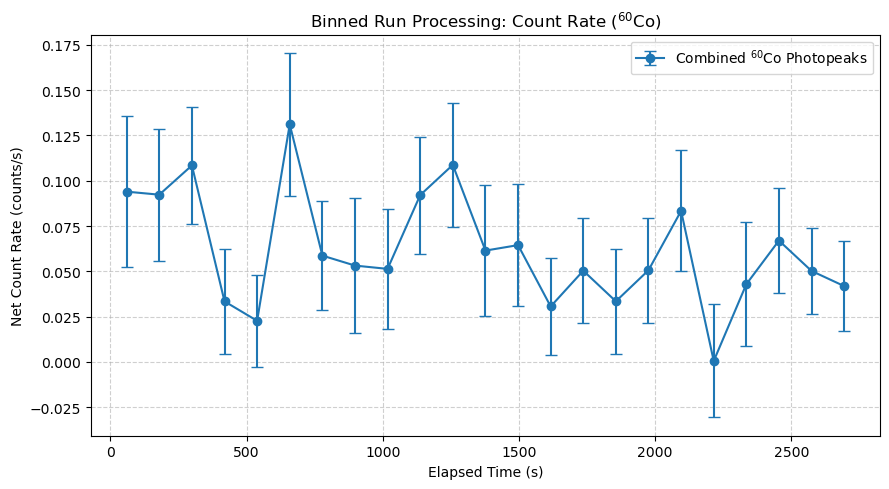

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import pathlib
import plotly.graph_objects as go
import plotly.io as pio

# ==============================================================================
# 1. CORE PEAK INTEGRATION FUNCTIONS
# ==============================================================================

def linear_bg(e, a, b):
    """Linear background function B(E) = a*E + b."""
    return a * e + b

def process_photopeak(energies, counts, peak_range, bg_left_range, bg_right_range):
    """
    Fits sidebands with a linear baseline, subtracts background, and integrates net counts.
    
    Parameters:
        energies (array): Array of energy values (MeV or Channel numbers).
        counts (array): Array of measured counts.
        peak_range (tuple): (E_min, E_max) Region of Interest (ROI) for the peak.
        bg_left_range (tuple): (E_min, E_max) Sideband region to the left of peak.
        bg_right_range (tuple): (E_min, E_max) Sideband region to the right of peak.
        
    Returns:
        dict containing net_counts, gross_counts, bg_counts, uncertainty, and fit parameters.
    """
    # Select masks for regions
    bg_mask = ((energies >= bg_left_range[0]) & (energies <= bg_left_range[1])) | \
              ((energies >= bg_right_range[0]) & (energies <= bg_right_range[1]))
    peak_mask = (energies >= peak_range[0]) & (energies <= peak_range[1])
    
    # Fit linear background to sidebands
    popt, _ = curve_fit(linear_bg, energies[bg_mask], counts[bg_mask])
    
    # Calculate counts in Peak ROI
    peak_energies = energies[peak_mask]
    peak_counts = counts[peak_mask]
    bg_in_peak = linear_bg(peak_energies, *popt)
    
    gross_counts = np.sum(peak_counts)
    bg_total = np.sum(bg_in_peak)
    net_counts = gross_counts - bg_total
    
    # Poisson statistical uncertainty
    uncertainty = np.sqrt(gross_counts + bg_total)
    
    return {
        "net_counts": net_counts,
        "gross_counts": gross_counts,
        "bg_counts": bg_total,
        "uncertainty": uncertainty,
        "popt": popt
    }


def load_and_bin_spectrum(filepath, bin_edges, raw_voltage=False):
    """
    Parses list-mode CSV. If raw_voltage=True, bins raw voltages directly.
    Otherwise, converts voltages to MeV using CALIB parameters before binning.
    """
    times = []
    voltages = []
    
    with open(filepath, 'r') as f:
        next(f)  # Skip header
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 2:
                try:
                    times.append(float(parts[-2]))
                    voltages.append(float(parts[-1]))
                except ValueError:
                    continue
                    
    time_s = np.array(times)
    duration_sec = time_s.max() - time_s.min() if len(time_s) > 0 else 1.0
    if duration_sec <= 0:
        duration_sec = 1.0

    voltages_arr = np.array(voltages)
    
    if raw_voltage:
        # Bin raw voltages directly without applying CALIB_M and CALIB_C
        counts, _ = np.histogram(voltages_arr, bins=bin_edges)
    else:
        # Convert voltages to energies (MeV) and bin
        event_energies = CALIB_M * voltages_arr + CALIB_C
        counts, _ = np.histogram(event_energies, bins=bin_edges)
    
    return counts, duration_sec

# Calibration parameters: E(V) = m * V + c
# Calibration from the linear fit of multiple known energy peaks
CALIB_M = 0.5923  # MeV / V
CALIB_C = 0.3994  # MeV


# don't need the background subtraction really, Kolomensky advised against it
def analyze_co60_spectrum(filepath, bg_filepath=None):
    """
    Processes a sample spectrum file and optionally subtracts a room background file.
    """
    bin_edges = np.linspace(0.4, 1.7, 1301)
    energies = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 1. Load and bin sample spectrum
    counts, duration_sec = load_and_bin_spectrum(filepath, bin_edges)

    # 2. Subtract room background if provided
    if bg_filepath is not None:
        bg_counts, bg_duration = load_and_bin_spectrum(bg_filepath, bin_edges)
        
        # Time-scaling factor k = T_sample / T_bg
        time_scale = duration_sec / bg_duration
        
        # Subtract normalized room background
        counts = counts - (time_scale * bg_counts)

    # 3. Integrate photopeaks (sideband fit strips the remaining Compton continuum)
    p1_res = process_photopeak(
        energies, counts,
        peak_range=(1.12, 1.22), bg_left_range=(1.05, 1.10), bg_right_range=(1.24, 1.28)
    )

    p2_res = process_photopeak(
        energies, counts,
        peak_range=(1.29, 1.37), bg_left_range=(1.24, 1.28), bg_right_range=(1.39, 1.43)
        
    )

    # 4. Calculate count rates 
    rate_117 = p1_res["net_counts"] / duration_sec
    rate_117_err = p1_res["uncertainty"] / duration_sec

    rate_133 = p2_res["net_counts"] / duration_sec
    rate_133_err = p2_res["uncertainty"] / duration_sec

    return {
        "filename": filepath.name,
        "duration_sec": duration_sec,
        "rate_117_MeV": rate_117,
        "err_117_MeV": rate_117_err,
        "rate_133_MeV": rate_133,
        "err_133_MeV": rate_133_err,
        "total_rate": rate_117 + rate_133,
        "total_err": np.sqrt(rate_117_err**2 + rate_133_err**2),
    }


def process_run_directory(data_dir, room_bg_file=None):
    directory = pathlib.Path(data_dir)
    results = []
    file_list = sorted(list(directory.glob("*.csv")))

    cumulative_time = 0.0
    for idx, filepath in enumerate(file_list):
        # Skip the room background file itself if stored in the same folder
        if room_bg_file and filepath.resolve() == pathlib.Path(room_bg_file).resolve():
            continue
            
        res = analyze_co60_spectrum(filepath, bg_filepath=room_bg_file)
        res["run_index"] = idx
        res["timestamp_sec"] = cumulative_time + (res["duration_sec"] / 2.0)
        cumulative_time += res["duration_sec"]
        results.append(res)

    return pd.DataFrame(results)

# Scrollable Histogram

def show_interactive_spectrum(filepath, v_min=0.0, v_max=2.2, num_bins=10000):
    """
    Generates an interactive, scrollable high-resolution Plotly histogram
    converting Voltage bin edges to MeV using calibration parameters.
    """
    # 1. Create voltage bin edges and convert to MeV via calibration
    v_edges = np.linspace(v_min, v_max, num_bins)
    bin_edges = CALIB_M * v_edges + CALIB_C
    energies = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 2. Load and bin data
    counts, _ = load_and_bin_spectrum(filepath, bin_edges)

    # 3. Create interactive Plotly figure
    fig = go.Figure(data=go.Scatter(
        x=energies, 
        y=counts, 
        mode='lines', 
        line_shape='hvh',
        fill='tozeroy',
        name='Counts',
        line=dict(width=1)
    ))

    fig.update_layout(
        title=f"High-Resolution Spectrum: {filepath.name} (Calibrated: E = {CALIB_M}*V + {CALIB_C})",
        xaxis_title="Energy (MeV)",
        yaxis_title="Counts",
        template="plotly_dark",
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="linear"
        ),
        yaxis=dict(fixedrange=False) 
    )

    fig.show(config={'scrollZoom': True})


def show_interactive_spectrum_folder(data_dir, v_min=0.0, v_max=2.2, num_bins=10000, room_bg_file=None):
    """
    Aggregates all CSV spectrum files in a directory into a combined high-resolution
    histogram using voltage calibration parameters.
    """
    directory = pathlib.Path(data_dir)
    file_list = sorted(list(directory.glob("*.csv")))
    
    if not file_list:
        print(f"No CSV files found in directory: {data_dir}")
        return

    # Create voltage bin edges and convert to MeV via calibration
    v_edges = np.linspace(v_min, v_max, num_bins)
    bin_edges = CALIB_M * v_edges + CALIB_C
    energies = (bin_edges[:-1] + bin_edges[1:]) / 2

    total_counts = np.zeros(len(energies))
    total_duration = 0.0
    files_processed = 0

    for filepath in file_list:
        if room_bg_file and filepath.resolve() == pathlib.Path(room_bg_file).resolve():
            continue
            
        counts, duration = load_and_bin_spectrum(filepath, bin_edges)
        total_counts += counts
        total_duration += duration
        files_processed += 1

    print(f"Aggregated {files_processed} files | Total live time: {total_duration:.1f} s")

    fig = go.Figure(data=go.Scatter(
        x=energies, 
        y=total_counts, 
        mode='lines', 
        line_shape='hvh', 
        fill='tozeroy',
        name='Cumulative Counts',
        line=dict(width=1)
    ))

    fig.update_layout(
        title=f"Combined Spectrum ({files_processed} Files | Total Duration: {total_duration:.1f}s | E = {CALIB_M}*V + {CALIB_C})",
        xaxis_title="Energy (MeV)",
        yaxis_title="Total Counts",
        template="plotly_dark",
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="linear"
        ),
        yaxis=dict(fixedrange=False)
    )

    fig.show(config={'scrollZoom': True})

def show_interactive_spectrum_folder_voltage(data_dir, v_min=0.0, v_max=2.2, num_bins=10000, room_bg_file=None):
    """
    Aggregates all CSV spectrum files in a directory into a combined high-resolution
    histogram using raw voltage bins.
    """
    directory = pathlib.Path(data_dir)
    file_list = sorted(list(directory.glob("*.csv")))
    
    if not file_list:
        print(f"No CSV files found in directory: {data_dir}")
        return

    # Create voltage bin edges and bin centers
    bin_edges = np.linspace(v_min, v_max, num_bins)
    voltages = (bin_edges[:-1] + bin_edges[1:]) / 2

    total_counts = np.zeros(len(voltages))
    total_duration = 0.0
    files_processed = 0

    for filepath in file_list:
        if room_bg_file and filepath.resolve() == pathlib.Path(room_bg_file).resolve():
            continue
            
        counts, duration = load_and_bin_spectrum(filepath, bin_edges, raw_voltage=True)
        total_counts += counts
        total_duration += duration
        files_processed += 1

    print(f"Aggregated {files_processed} files | Total live time: {total_duration:.1f} s")

    fig = go.Figure(data=go.Scatter(
        x=voltages, 
        y=total_counts, 
        mode='lines', 
        line_shape='hvh', 
        fill='tozeroy',
        name='Cumulative Counts',
        line=dict(width=1)
    ))

    fig.update_layout(
        title=f"Combined Spectrum ({files_processed} Files | Total Duration: {total_duration:.1f}s)",
        xaxis_title="Pulse Height (V)",
        yaxis_title="Total Counts",
        template="plotly_dark",
        xaxis=dict(
            rangeslider=dict(visible=True),
            type="linear"
        ),
        yaxis=dict(fixedrange=False)
    )

    fig.show(config={'scrollZoom': True})

# ==============================================================================
# 3. GENERATE MOCK DATA & RUN PIPELINE
# ==============================================================================

'''
def generate_mock_spectra_files(output_dir, num_runs=10):
    """Generates synthetic Co-60 MCA spectrum files simulating a cooling cryostat."""
    pathlib.Path(output_dir).mkdir(parents=True, exist_ok=True)
    energies = np.linspace(0.8, 1.5, 1000)
    
    for i in range(num_runs):
        # Simulate anisotropic count rate drop as cryostat cools (theta = 0 deg)
        anisotropy_factor = 1.0 - 0.03 * (i / num_runs) 
        
        # Continuum Compton background
        compton_bg = 200 - 100 * (energies - 0.8)
        
        # 1.17 MeV and 1.33 MeV Gaussian photopeaks
        p1 = 800 * anisotropy_factor * np.exp(-((energies - 1.17)**2) / (2 * 0.015**2))
        p2 = 700 * anisotropy_factor * np.exp(-((energies - 1.33)**2) / (2 * 0.015**2))
        
        # Poisson noise
        mean_counts = compton_bg + p1 + p2
        noisy_counts = np.random.poisson(np.maximum(mean_counts, 0))
        
        df = pd.DataFrame({"Energy_MeV": energies, "Counts": noisy_counts})
        df.to_csv(f"{output_dir}/run_{i:03d}.csv", index=False)
'''



if __name__ == "__main__":

    data_folder = "./above_100K_co60"
    
    show_interactive_spectrum_folder_voltage(data_folder, v_min=0.0, v_max=2.2, num_bins=10000, room_bg_file=None)

    # Optional: Pick one file to inspect interactively before running the batch

    sample_file = list(pathlib.Path(data_folder).glob("*.csv"))[0]
    show_interactive_spectrum(sample_file, num_bins=10000)

    show_interactive_spectrum_folder(data_folder, num_bins=10000)
    
    # 2. Process all runs (assuming 120s duration per short run)
    summary_df = process_run_directory(data_folder)
    
    print("\n=== BATCH PROCESSING SUMMARY ===")
    print(summary_df[["run_index", "timestamp_sec", "rate_117_MeV", "rate_133_MeV", "total_rate"]])
    
    # 3. Plot Count Rates vs. Time
    plt.figure(figsize=(9, 5))
    plt.errorbar(
        summary_df["timestamp_sec"], 
        summary_df["total_rate"], 
        yerr=summary_df["total_err"],
        fmt='o-', capsize=4, label=r"Combined $^{60}\text{Co}$ Photopeaks"
    )
    plt.xlabel("Elapsed Time (s)")
    plt.ylabel("Net Count Rate (counts/s)")
    plt.title(r"Binned Run Processing: Count Rate ($^{60}\text{Co}$)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    